
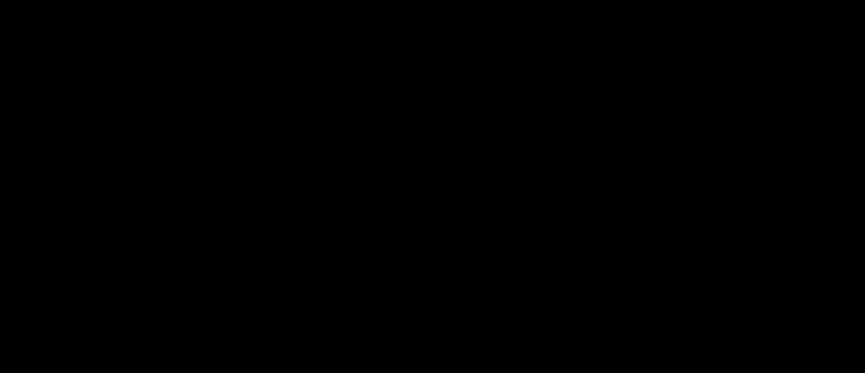
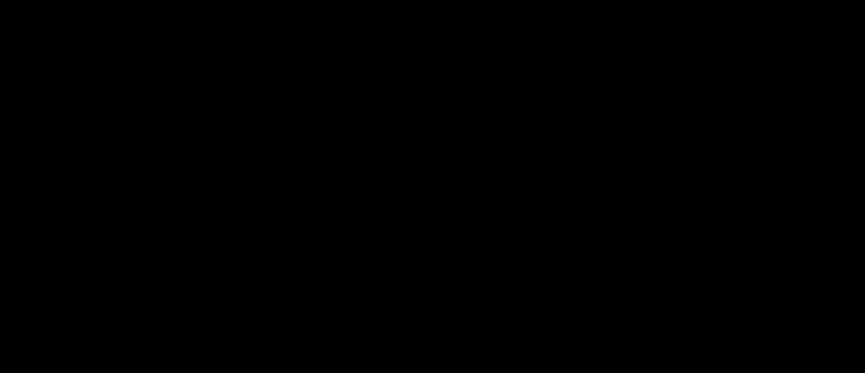

In [37]:
#Bunlar dersteki Python kütüphaneleri
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import arff
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix, roc_auc_score

file_path = 'data/diabetic+retinopathy+debrecen/messidor_features.arff' #arff dosyası bizim veriyi aldığımız dosyadır. Onu bir değşkene (obje) eşitliyoruz ki istediğimizde çağırabilelim.
data, meta = arff.loadarff(file_path)
df = pd.DataFrame(data)
print(df)


X = df.iloc[:, :-1] #Bu kod tüm satırları alırken, en son sütunu almıyor. Sebebi ise sadece y ekseninde bize lazım olması.

y = df.iloc[:, -1].to_frame() #Bu kod aynı şekilde tüm satırları alırken bu sefer sadece son sütunu alıyor.

# y'deki byte stringleri (b'0', b'1') temiz sayıya (0, 1) çevirme
# (Bu, veriyi modelin anlayacağı sayısal formata getirir. Ders slaytlarında bu decoding vardı.)
y['Class'] = y['Class'].str.decode('utf-8').astype(int)


        0    1     2     3     4     5     6     7          8          9  \
0     1.0  1.0  22.0  22.0  22.0  19.0  18.0  14.0  49.895756  17.775994   
1     1.0  1.0  24.0  24.0  22.0  18.0  16.0  13.0  57.709936  23.799994   
2     1.0  1.0  62.0  60.0  59.0  54.0  47.0  33.0  55.831441  27.993933   
3     1.0  1.0  55.0  53.0  53.0  50.0  43.0  31.0  40.467228  18.445954   
4     1.0  1.0  44.0  44.0  44.0  41.0  39.0  27.0  18.026254   8.570709   
...   ...  ...   ...   ...   ...   ...   ...   ...        ...        ...   
1146  1.0  1.0  34.0  34.0  34.0  33.0  31.0  24.0   6.071765   0.937472   
1147  1.0  1.0  49.0  49.0  49.0  49.0  45.0  37.0  63.197145  27.377668   
1148  1.0  0.0  49.0  48.0  48.0  45.0  43.0  33.0  30.461898  13.966980   
1149  1.0  1.0  39.0  36.0  29.0  23.0  13.0   7.0  40.525739  12.604947   
1150  1.0  1.0   7.0   7.0   7.0   7.0   7.0   5.0  69.423565   7.031843   

             10        11        12        13        14        15        16  \
0      5

In [38]:
X.info() #Bu kod satırı bize verilerde herhangi bir null değer var mı onu gösteriyor. 0'dan 18'e kadar olan sütunların hepsindeki 1151 satırdaki değerler non-null. O yüzden eksik veri yok. Yani imputation işlemi yapmıyoruz.
X.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1151 entries, 0 to 1150
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       1151 non-null   float64
 1   1       1151 non-null   float64
 2   2       1151 non-null   float64
 3   3       1151 non-null   float64
 4   4       1151 non-null   float64
 5   5       1151 non-null   float64
 6   6       1151 non-null   float64
 7   7       1151 non-null   float64
 8   8       1151 non-null   float64
 9   9       1151 non-null   float64
 10  10      1151 non-null   float64
 11  11      1151 non-null   float64
 12  12      1151 non-null   float64
 13  13      1151 non-null   float64
 14  14      1151 non-null   float64
 15  15      1151 non-null   float64
 16  16      1151 non-null   float64
 17  17      1151 non-null   float64
 18  18      1151 non-null   float64
dtypes: float64(19)
memory usage: 171.0 KB


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,1.0,1.0,22.0,22.0,22.0,19.0,18.0,14.0,49.895756,17.775994,5.270920,0.771761,0.018632,0.006864,0.003923,0.003923,0.486903,0.100025,1.0
1,1.0,1.0,24.0,24.0,22.0,18.0,16.0,13.0,57.709936,23.799994,3.325423,0.234185,0.003903,0.003903,0.003903,0.003903,0.520908,0.144414,0.0
2,1.0,1.0,62.0,60.0,59.0,54.0,47.0,33.0,55.831441,27.993933,12.687485,4.852282,1.393889,0.373252,0.041817,0.007744,0.530904,0.128548,0.0
3,1.0,1.0,55.0,53.0,53.0,50.0,43.0,31.0,40.467228,18.445954,9.118901,3.079428,0.840261,0.272434,0.007653,0.001531,0.483284,0.114790,0.0
4,1.0,1.0,44.0,44.0,44.0,41.0,39.0,27.0,18.026254,8.570709,0.410381,0.000000,0.000000,0.000000,0.000000,0.000000,0.475935,0.123572,0.0


In [39]:
y.value_counts() #Bu kod satırı da bize verilerimizin degeli olduğunu gösteriyor. Yani hasta olanlar ve olmayanların sayısı orantısal olarak birbirine yakın olduğundan veri setimizi ekstradan düzenlememize gerek yok.

Class
1        611
0        540
Name: count, dtype: int64

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y) #Verimizin yüzde 80'i eğitim, kalanı eğitim için kullanılacak. Stratify = y, classların yani hasta/hasta değil oranlarını sabit tutar her set için.

print(y_train.value_counts(normalize=True)) #Yukarıda yaptığımızın aynısı. Stratify durumu kontrol ediyor. Oran aynı sıkıntı yok.

Class
1        0.530435
0        0.469565
Name: proportion, dtype: float64


In [41]:
scaler = StandardScaler()#Scaler tanımlıyoruz. Değeri 1000'li olanla 10'lu olan aynı ağırlıkta. KNN'de falan önemli bunlar.

X_train_scaled = scaler.fit_transform(X_train)#Standadizasyon için standart sapma lazım. Onu sadece burda hesaplıyoruz. Sonra X_traini standardize ediyoruz.

X_test_scaled = scaler.transform(X_test)#Standardizasyonu burda da yapıyoruz ama burda standart sapmayı bulmuyoruz. Burda standart sapma bulma yok çünkü testten bu değeri alırsak model buna göre eğitilebilir. Overfit olabilir.


In [42]:
#Burdan sonra birkaç model eğitip, iyi olanı seçmeye çalışacağız. F1 falan filan burda devreye giriyor.

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "k-NN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(random_state=42, gamma="auto"),
    "Random Forest": RandomForestClassifier(random_state=42),
}
results = {}

for name, model in models.items():

    cv_scores = cross_val_score(model, X_train_scaled, y_train.values.ravel(), scoring = "f1", cv=5)#Cross validation 5 ile F1 hesabı.
    results[name] = cv_scores.mean()

print(pd.Series(results).sort_values(ascending=False))
#Neden F1 bu kadar önemli. Çünkü Precision veya Recall'a ayrı ayrı bakmaktansa, ikisininde belli miktar yüksek olması gerekiyor. Yani hem yanlış alarm vermemesini, hem de halihazırda hasta olanları kaçırmamak amacımız.

Logistic Regression    0.710105
SVM (SVC)              0.702095
Random Forest          0.682643
k-NN                   0.624721
dtype: float64


In [43]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

#Burdaki değerleri slaytlardan ve internetten aldık. Genel olarak bu değerler kullanılıyor.
param_grid_svc = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10, 100]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100], 'gamma': [0.01, 0.1, 1]}
]

svc = SVC(random_state=42)

grid_search_svc = GridSearchCV(svc, param_grid_svc, cv=5,
                               scoring='f1', verbose=2, n_jobs=-1)

#Grid Search çalıştır. Bu bize en iyi ayarı buluyor. Çalışma mantığı o yazdıklarımızın kombinasyonlarını deniyor.
grid_search_svc.fit(X_train_scaled, y_train.values.ravel())

# 5. Sonuçları yazdıralım
print(f"Parametre sonuçları: {grid_search_svc.best_params_}")
print(f"En iyi parametrelerle F1 Skoru: {grid_search_svc.best_score_:.4f}")

SVC için en iyi parametreler aranıyor...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

--- SVC Fine-Tuning Sonuçları ---
En İyi Parametreler: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
En İyi F1 Skoru: 0.7373


In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

#Değerleri yine slaytlardan ve internetten bulduk.
param_grid_lr = [
    {'C': [0.1, 1, 10, 100], 'solver': ['lbfgs', 'liblinear']}
]

logistic = LogisticRegression(max_iter=5000, random_state=42)

#Yine Grid Search yapıyoruz. Ve yine cross-val 5'te.
grid_search_lr = GridSearchCV(logistic, param_grid_lr, cv=5, scoring='f1')

# 4. Eğitimi başlat
print("Logistic Regression için en iyi parametreler aranıyor...")
grid_search_lr.fit(X_train_scaled, y_train.values.ravel())

print("--- Logistic Regression Sonuçları ---")
print(f"Parametre sonuçları: {grid_search_lr.best_params_}")
print(f"En iyi parametrelerle F1 Skoru: {grid_search_lr.best_score_:.4f}")

Logistic Regression için en iyi parametreler aranıyor...
--- Logistic Regression Sonuçları ---
En İyi Parametreler: {'C': 10, 'solver': 'lbfgs'}
En İyi F1 Skoru: 0.7301


In [45]:
from sklearn.ensemble import RandomForestClassifier

# 1. Denenecek parametrelerin listesini oluşturuyoruz
# Ch7 mantığına uygun olarak ağaç sayısını ve özellik kısıtlamalarını deniyoruz
param_grid_rf = [
    {'n_estimators': [100, 200, 500],
     'max_features': ['sqrt', 'log2'], # Slaytlardaki tipik seçimler
     'max_depth': [None, 10, 20],      # None: ağaçlar tam büyür
     'random_state': [42]}
]


rf = RandomForestClassifier()

#Yukarıdakilerin aynısı. Grid Search kur sonra cross-val yap.
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5,
                               scoring='f1', verbose=2, n_jobs=-1)

grid_search_rf.fit(X_train_scaled, y_train.values.ravel())

print(f"Parametre sonuçları: {grid_search_rf.best_params_}")
print(f"En iyi parametrelerle F1 skoru: {grid_search_rf.best_score_:.4f}")

Random Forest için en iyi parametreler aranıyor...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

--- Random Forest Fine-Tuning Sonuçları ---
En İyi Parametreler: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 200, 'random_state': 42}
En İyi F1 Skoru: 0.6922


In [58]:
from sklearn.ensemble import VotingClassifier


best_lr = grid_search_lr.best_estimator_
best_svc = grid_search_svc.best_estimator_
# SVC'nin 'soft voting' yapabilmesi için olasılık desteğini açıyoruz
best_svc.set_params(probability=True)
best_rf = grid_search_rf.best_estimator_

# 2. Oylama Sınıflandırıcısını oluşturuyoruz
# Hem sert hem yumuşak oylamayı deneyebiliriz, biz 'soft' ile başlayacağız
voting_clf = VotingClassifier(
    estimators=[('lr', best_lr), ('svc', best_svc), ('rf', best_rf)],
    voting='soft'
)

# 3. Topluluk modelini 5-katlı Cross-Validation ile test edelim
from sklearn.model_selection import cross_val_score
voting_scores = cross_val_score(voting_clf, X_train_scaled, y_train.values.ravel(),
                                cv=5, scoring='f1')

print(f"--- Voting Classifier (Ensemble) Sonucu ---")
print(f"Ortalama F1 Skoru: {voting_scores.mean():.4f}")

--- Voting Classifier (Ensemble) Sonucu ---
Ortalama F1 Skoru: 0.7521


In [47]:
from sklearn.metrics import classification_report, accuracy_score

# 1. Topluluk modelimizi (Voting Classifier) tüm eğitim verisiyle tekrar eğitiyoruz
# (Cross-validation sadece kontrol içindi, şimdi tüm imkanlarıyla öğrensin)
voting_clf.fit(X_train_scaled, y_train.values.ravel())

# 2. Hiç görülmemiş TEST SETİ üzerinde tahmin yapıyoruz
y_pred = voting_clf.predict(X_test_scaled)

# 3. Sonuçları raporlayalım
print(classification_report(y_test, y_pred))

# Accuracy değerini ayrıca görelim
acc = accuracy_score(y_test, y_pred)
print(f"Final Accuracy (Doğruluk): %{acc*100:.2f}")

--- AŞAMA G: TEST SETİ NİHAİ SONUÇLARI ---
              precision    recall  f1-score   support

           0       0.72      0.85      0.78       108
           1       0.84      0.71      0.77       123

    accuracy                           0.77       231
   macro avg       0.78      0.78      0.77       231
weighted avg       0.79      0.77      0.77       231

Final Accuracy (Doğruluk): %77.49


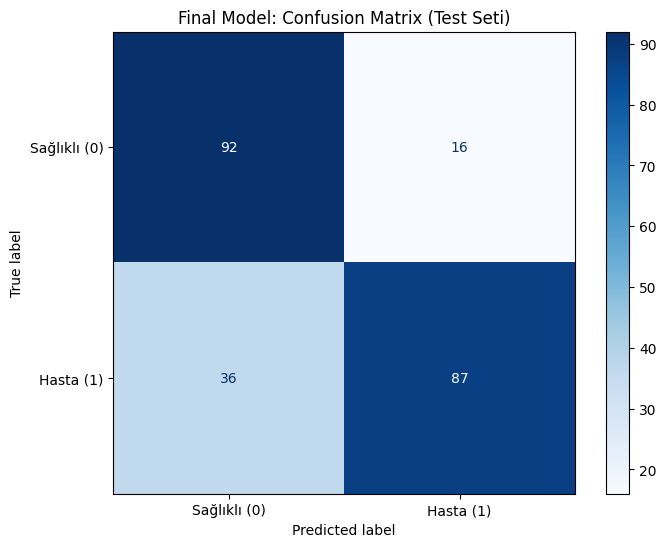

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Matrisi hesaplıyoruz
cm = confusion_matrix(y_test, y_pred)

# 2. Görselleştirme (ConfusionMatrixDisplay, Ch3'teki mantığı pratikleştirir)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sağlıklı (0)', 'Hasta (1)'])

# 3. Çizimi yapalım
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Final Model: Confusion Matrix (Test Seti)')
plt.show()

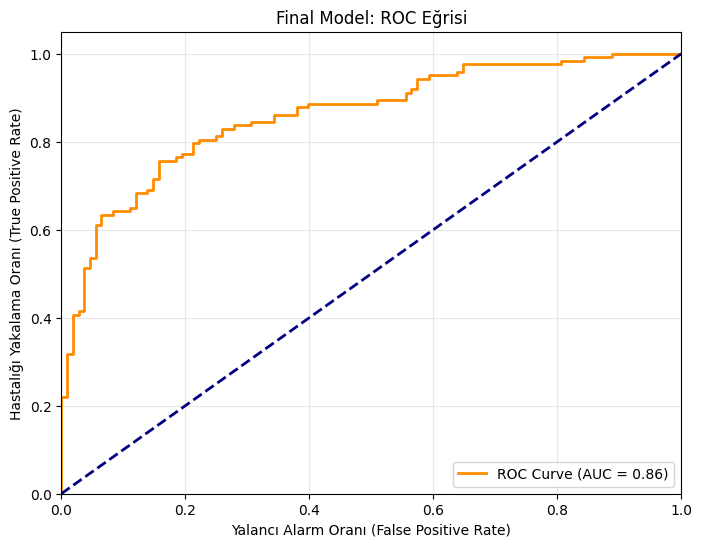

Modelin Toplam Başarı Puanı (AUC): 0.8612


In [49]:
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Modelimizin olasılık tahminlerini alıyoruz (Sadece 'Hasta (1)' olma olasılığı)
y_probs = voting_clf.predict_proba(X_test_scaled)[:, 1]

# 2. ROC eğrisi için gerekli değerleri hesaplıyoruz
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# 3. AUC skorunu hesaplıyoruz
auc_score = roc_auc_score(y_test, y_probs)

# 4. Grafiği çizdirelim
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Köşegen (şans çizgisi)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yalancı Alarm Oranı (False Positive Rate)')
plt.ylabel('Hastalığı Yakalama Oranı (True Positive Rate)')
plt.title('Final Model: ROC Eğrisi')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Modelin Toplam Başarı Puanı (AUC): {auc_score:.4f}")

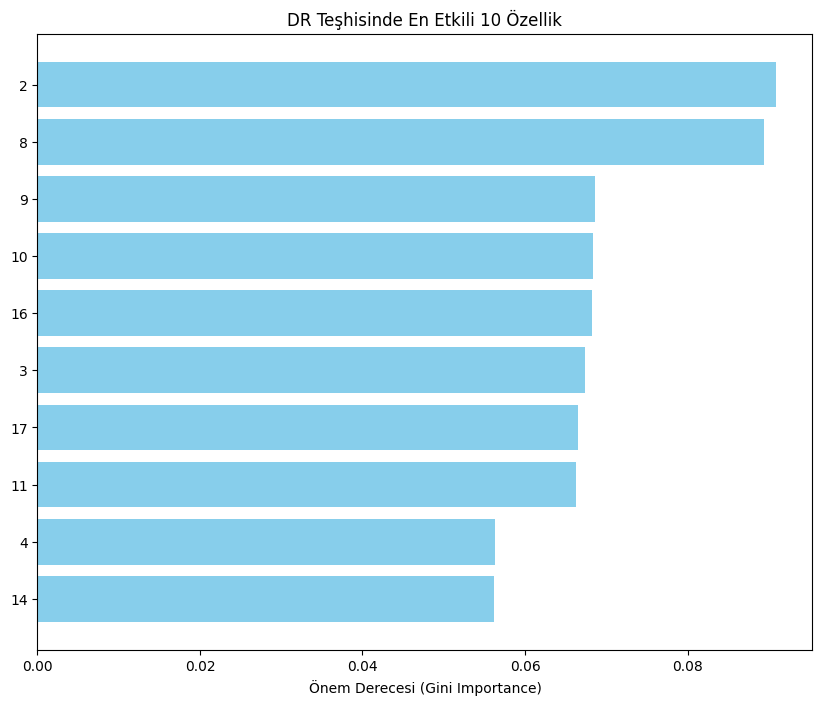

En önemli 3 özellik:
  Özellik      Önem
2       2  0.090836
8       8  0.089430
9       9  0.068576


In [50]:
import pandas as pd
import numpy as np

# 1. Eğittiğimiz en iyi Random Forest modelinden önem derecelerini alıyoruz
# (Burada best_rf, daha önce oluşturduğumuz grid_search_rf.best_estimator_ nesnesidir)
importances = best_rf.feature_importances_

# 2. Özellik isimlerini (20 adet) alalım (X_train verisindeki sütun adları)
feature_names = X.columns

# 3. Bunları bir DataFrame yapıp sıralayalım
feature_importance_df = pd.DataFrame({'Özellik': feature_names, 'Önem': importances})
feature_importance_df = feature_importance_df.sort_values(by='Önem', ascending=False)

# 4. Grafik olarak bastıralım
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Özellik'].head(10), feature_importance_df['Önem'].head(10), color='skyblue')
plt.xlabel('Önem Derecesi (Gini Importance)')
plt.title('DR Teşhisinde En Etkili 10 Özellik')
plt.gca().invert_yaxis() # En önemliyi en üste al
plt.show()

print("En önemli 3 özellik:")
print(feature_importance_df.head(3))